<a href="https://colab.research.google.com/github/hemashree124/Telecom_repo/blob/main/HP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# [1. Data Loading & Preprocessing]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [55]:
# Load dataset
df = pd.read_excel('/content/drive/MyDrive/Airbnb Properties Information.xlsx')

In [56]:
print(df.columns)

Index(['name', 'price', 'image', 'description', 'category', 'availability',
       'discount', 'reviews', 'ratings', 'seller_info', 'breadcrumbs',
       'location', 'lat', 'long', 'guests', 'pets_allowed',
       'description_items', 'category_rating', 'house_rules', 'details',
       'highlights', 'arrangement_details', 'amenities', 'images',
       'available_dates', 'url', 'final_url', 'listing_title', 'property_id',
       'listing_name', 'location_details', 'description_by_sections',
       'description_html', 'location_details_html', 'is_supperhost',
       'host_number_of_reviews', 'host_rating', 'hosts_year',
       'host_response_rate', 'is_guest_favorite', 'travel_details',
       'pricing_details', 'total_price', 'currency', 'cancellation_policy',
       'property_number_of_reviews'],
      dtype='object')


In [57]:
# Convert availability to binary (1=Available, 0=Booked)
df['availability'] = df['available_dates'].apply(lambda x: 1 if len(x) > 0 else 0)

In [58]:
# Feature engineering
df['num_amenities'] = df['amenities'].apply(lambda x: len(eval(x)))
df['host_response_rate'] = df['host_response_rate'].fillna(0).astype(float)
df['is_guest_favorite'] = df['is_guest_favorite'].fillna(0).astype(int)
df['total_price']= df['total_price'].fillna(0).astype(float)

In [59]:
# Select features
features = ['price', 'ratings', 'num_amenities', 'host_response_rate',
           'host_rating','total_price']

X = df[features]
y = df['availability']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [60]:
# Handle missing values
X = X.fillna(X.mean())

# 1. Availability Prediction Model

Cross-validation scores: [0.97 0.97 0.98 0.96 0.96]
Mean CV score: 0.9680
Availability Prediction Accuracy: 95.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.17      0.18         6
           1       0.97      0.98      0.98       194

    accuracy                           0.95       200
   macro avg       0.59      0.57      0.58       200
weighted avg       0.95      0.95      0.95       200



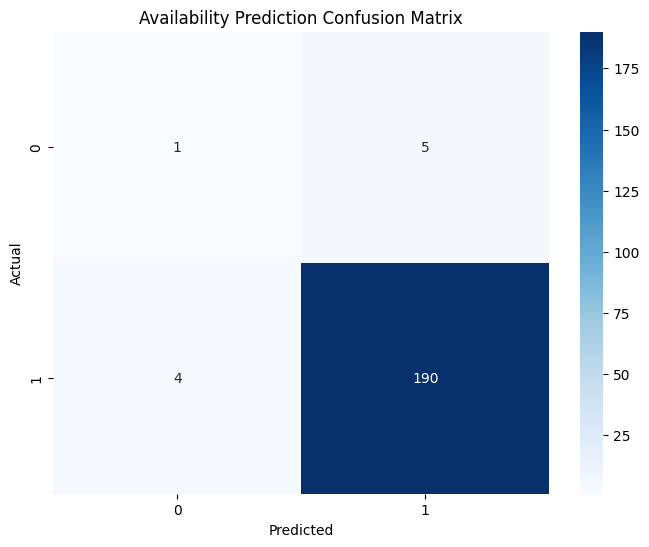

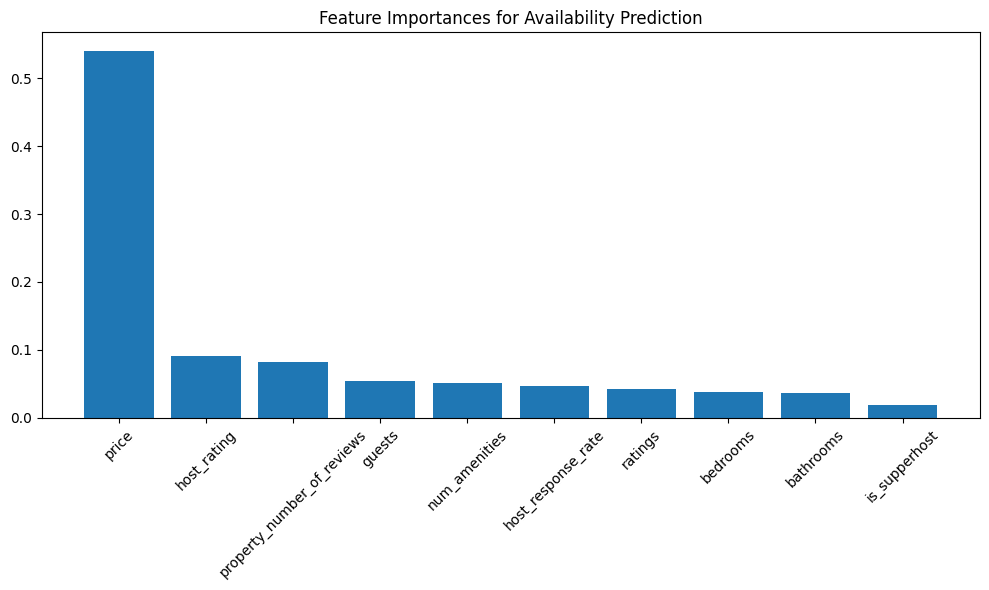

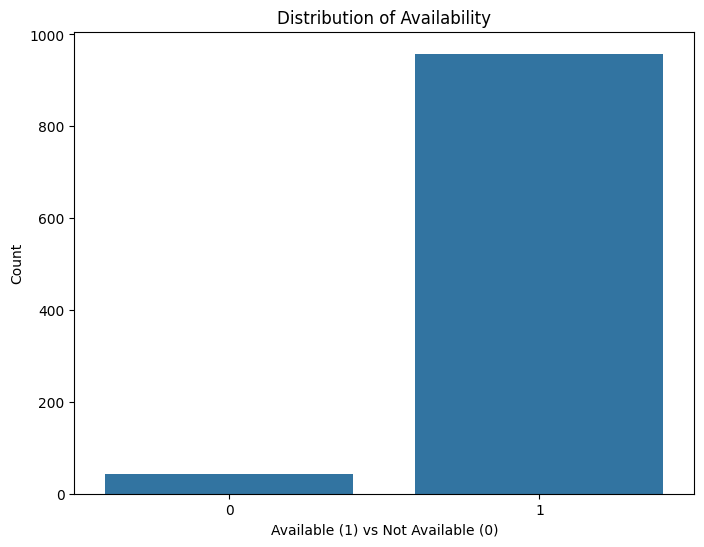

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import ast
import re


# Feature extraction
def extract_number_from_list(lst, keyword):
    for item in lst:
        if keyword in item.lower():
            match = re.search(r'(\d+)', item)
            if match:
                return int(match.group(1))
    return 0

# Convert string representation of lists to actual lists
df['details_list'] = df['details'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['amenities_list'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['available_dates_list'] = df['available_dates'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Extract features
df['bedrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bedroom'))
df['bathrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bath'))
df['num_amenities'] = df['amenities_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['availability'] = df['available_dates_list'].apply(lambda x: 1 if len(x) > 0 else 0)

# Convert numeric fields
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce').fillna(0)
df['host_rating'] = pd.to_numeric(df['host_rating'], errors='coerce').fillna(0)
df['property_number_of_reviews'] = pd.to_numeric(df['property_number_of_reviews'], errors='coerce').fillna(0)
df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(df['price'].median())

# Convert host_response_rate from string percentage to float
def convert_response_rate(x):
    if pd.isnull(x):
        return 0.0
    if isinstance(x, str) and x.endswith('%'):
        return float(x.strip('%'))
    try:
        return float(x)
    except:
        return 0.0

df['host_response_rate'] = df['host_response_rate'].apply(convert_response_rate)
df['is_supperhost'] = df['is_supperhost'].fillna(0).astype(int)

# Prepare features for availability prediction
features = ['price', 'ratings', 'host_rating', 'host_response_rate', 'guests',
            'bedrooms', 'bathrooms', 'num_amenities', 'property_number_of_reviews',
            'is_supperhost']
X = df[features].fillna(0)
y = df['availability']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f}")

# Predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Availability Prediction Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Availability Prediction Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature Importances for Availability Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(8,6))
sns.countplot(x=y)
plt.title('Distribution of Availability')
plt.xlabel('Available (1) vs Not Available (0)')
plt.ylabel('Count')
plt.show()


#Price Prediction

In [62]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import ast
import re

In [63]:
# Feature extraction
def extract_number_from_list(lst, keyword):
    for item in lst:
        if keyword in item.lower():
            match = re.search(r'(\d+)', item)
            if match:
                return int(match.group(1))
    return 0

In [64]:
# Convert string representation of lists to actual lists
df['details_list'] = df['details'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['amenities_list'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])


In [65]:
# Extract features
df['bedrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x,'bedroom'))
df['bathrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bath'))
df['num_amenities'] = df['amenities_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [66]:
# Convert ratings and host_rating to numeric
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce').fillna(0)
df['host_rating'] = pd.to_numeric(df['host_rating'], errors='coerce').fillna(0)
df['property_number_of_reviews'] = pd.to_numeric(df['property_number_of_reviews'], errors='coerce').fillna(0)

In [67]:
# Convert host_response_rate from string percentage to float
def convert_response_rate(x):
    if pd.isnull(x):
        return 0.0
    if isinstance(x, str) and x.endswith('%'):
        return float(x.strip('%'))
    try:
        return float(x)
    except:
        return 0.0


In [68]:
df['host_response_rate'] = df['host_response_rate'].apply(convert_response_rate)

In [69]:
# Prepare features for price prediction
features = ['ratings', 'host_rating', 'host_response_rate', 'guests',
            'bedrooms', 'bathrooms', 'num_amenities', 'property_number_of_reviews']
X = df[features].fillna(0)
y = df['price'].fillna(df['price'].median())

In [70]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
# Train model
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=200, random_state=42)

In [72]:
# Predictions
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [73]:
print(f"Price Prediction R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

Price Prediction R² Score: 0.2220
RMSE: 73.47


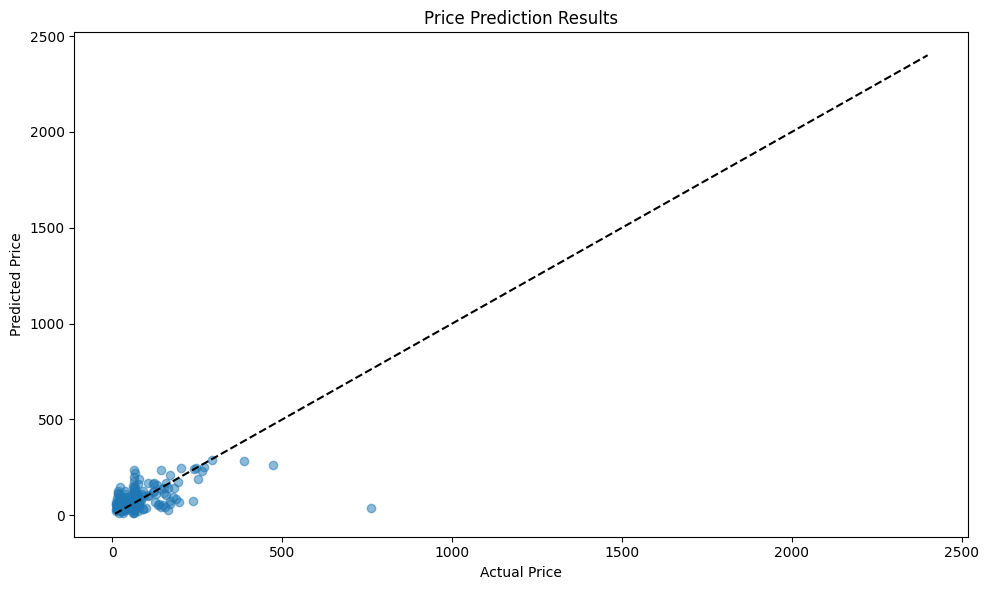

In [74]:
# Visualizations
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Price Prediction Results')
plt.tight_layout()
plt.show()

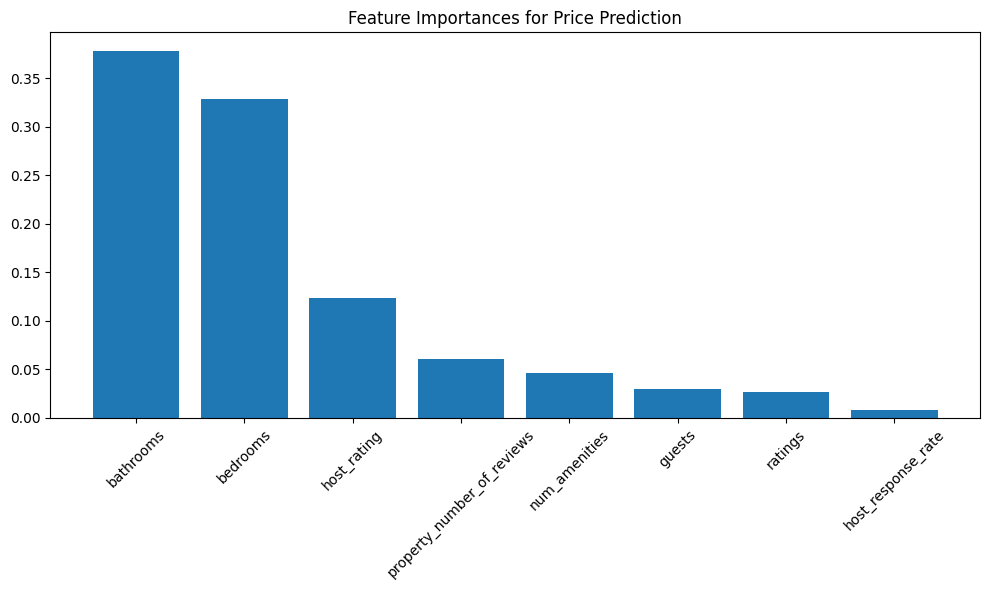

In [75]:
# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature Importances for Price Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

# 3. Rating Prediction (Regression)

In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
# Feature extraction
def extract_number_from_list(lst, keyword):
    for item in lst:
        if keyword in item.lower():
            match = re.search(r'(\d+)', item)
            if match:
                return int(match.group(1))
    return 0

In [78]:
# Convert string representation of lists to actual lists
df['details_list'] = df['details'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['amenities_list'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

In [79]:

# Extract features
df['bedrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bedroom'))
df['bathrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bath'))
df['num_amenities'] = df['amenities_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [80]:
# Convert host_rating and other numeric fields
df['host_rating'] = pd.to_numeric(df['host_rating'], errors='coerce').fillna(0)
df['property_number_of_reviews'] = pd.to_numeric(df['property_number_of_reviews'], errors='coerce').fillna(0)
df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(df['price'].median())

In [81]:
# Convert host_response_rate from string percentage to float
def convert_response_rate(x):
    if pd.isnull(x):
        return 0.0
    if isinstance(x, str) and x.endswith('%'):
        return float(x.strip('%'))
    try:
        return float(x)
    except:
        return 0.0

In [82]:
df['host_response_rate'] = df['host_response_rate'].apply(convert_response_rate)
df['is_supperhost'] = df['is_supperhost'].fillna(0).astype(int)

In [83]:
# Prepare features for rating prediction
features = ['price', 'host_rating', 'host_response_rate', 'guests',
            'bedrooms', 'bathrooms', 'num_amenities', 'property_number_of_reviews',
            'is_supperhost']
X = df[features].fillna(0)
y = df['ratings'].fillna(df['ratings'].median())

In [84]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# Train model
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [86]:
# Predictions
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [87]:
print(f"Rating Prediction R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

Rating Prediction R² Score: 0.9460
RMSE: 0.43


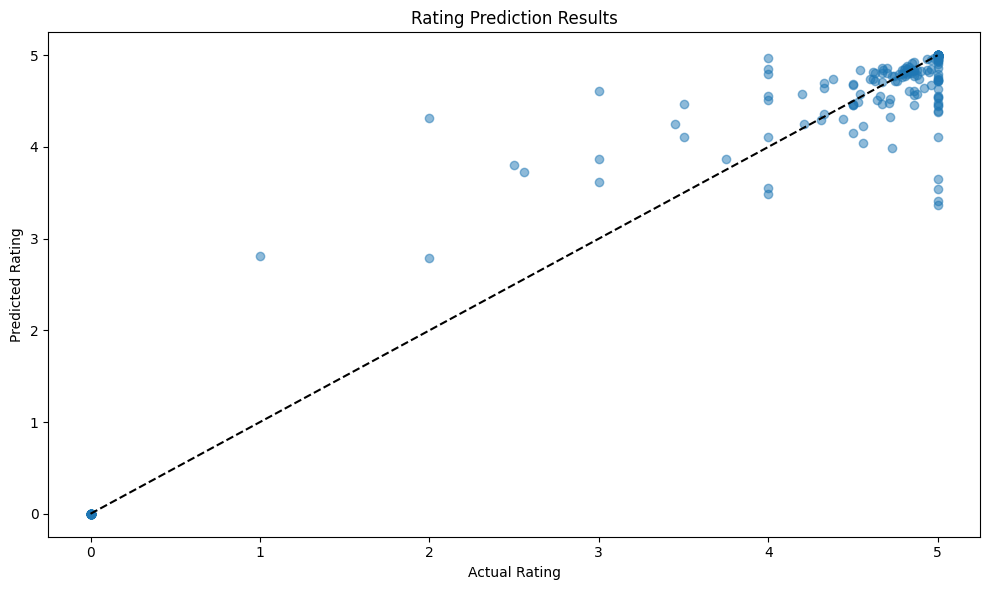

In [88]:
# Visualizations
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Rating Prediction Results')
plt.tight_layout()
plt.show()

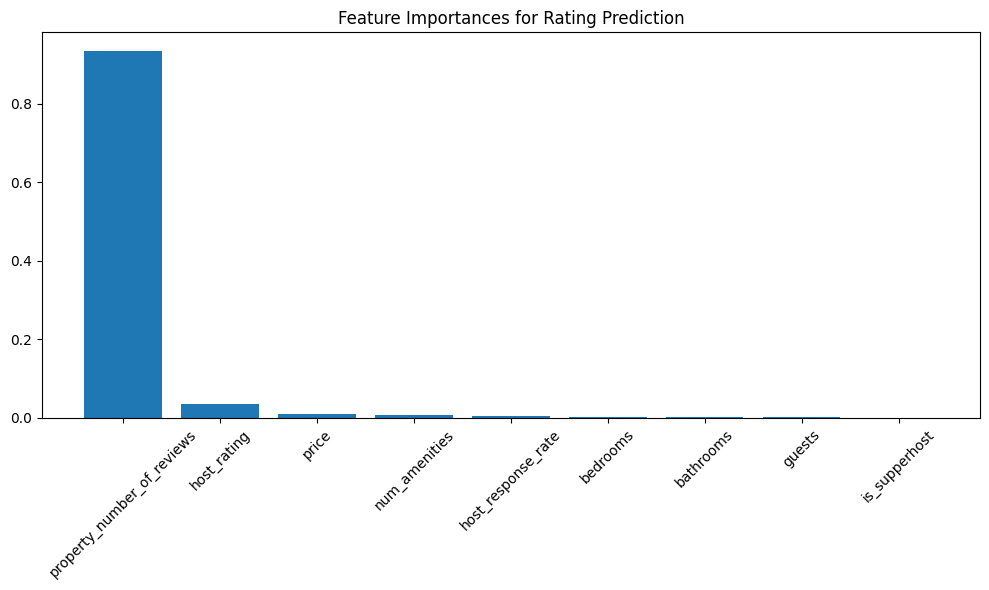

In [89]:
# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature Importances for Rating Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

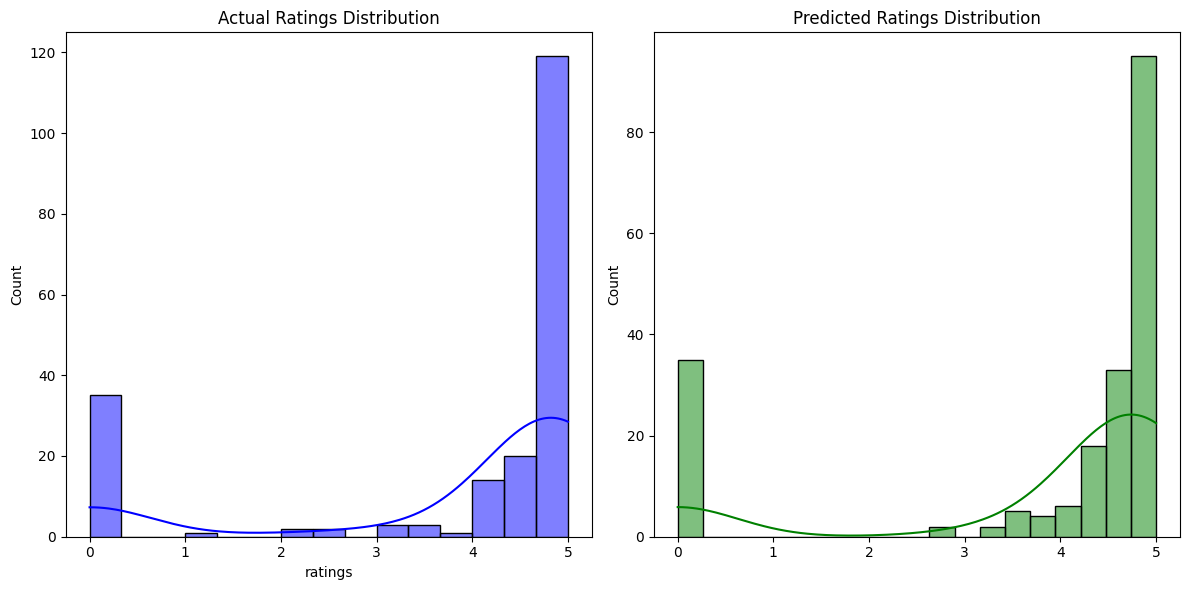

In [90]:
# Distribution of actual vs predicted ratings
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(y_test, kde=True, color='blue')
plt.title('Actual Ratings Distribution')
plt.subplot(1,2,2)
sns.histplot(y_pred, kde=True, color='green')
plt.title('Predicted Ratings Distribution')
plt.tight_layout()
plt.show()

#3. Guest Favorite Prediction

In [91]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [92]:

df['is_guest_favorite'] = df['is_guest_favorite'].fillna(0).astype(int)

In [93]:
# Create additional features
df['has_pool'] = df['amenities_list'].apply(lambda x: 1 if any('pool' in str(item).lower() for item in x) else 0)
df['has_wifi'] = df['amenities_list'].apply(lambda x: 1 if any('wifi' in str(item).lower() for item in x) else 0)
df['has_kitchen'] = df['amenities_list'].apply(lambda x: 1 if any('kitchen' in str(item).lower() for item in x) else 0)
df['has_ac'] = df['amenities_list'].apply(lambda x: 1 if any('air conditioning' in str(item).lower() for item in x) else 0)

In [94]:
# Prepare features for guest favorite prediction
features = ['price', 'ratings', 'host_rating', 'host_response_rate', 'guests',
            'bedrooms', 'bathrooms', 'num_amenities', 'property_number_of_reviews',
            'is_supperhost', 'has_pool', 'has_wifi', 'has_kitchen', 'has_ac']
X = df[features].fillna(0)
y = df['is_guest_favorite']


In [95]:
# Split data with stratification to handle imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [96]:
# Train model with hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'class_weight': ['balanced', 'balanced_subsample', None]
}


In [97]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


In [98]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'class_weight': None, 'max_depth': 10, 'n_estimators': 200}


In [99]:
# Predictions
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Guest Favorite Prediction Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Guest Favorite Prediction Accuracy: 94.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       160
           1       0.89      0.80      0.84        40

    accuracy                           0.94       200
   macro avg       0.92      0.89      0.90       200
weighted avg       0.94      0.94      0.94       200



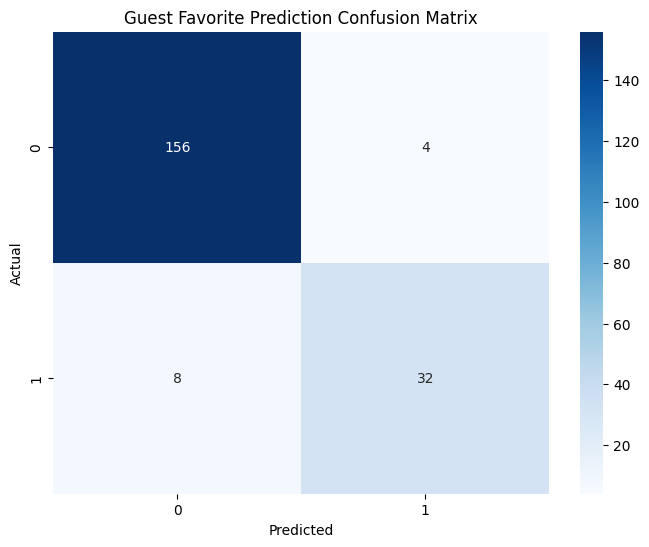

In [100]:
# Visualizations
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Guest Favorite Prediction Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

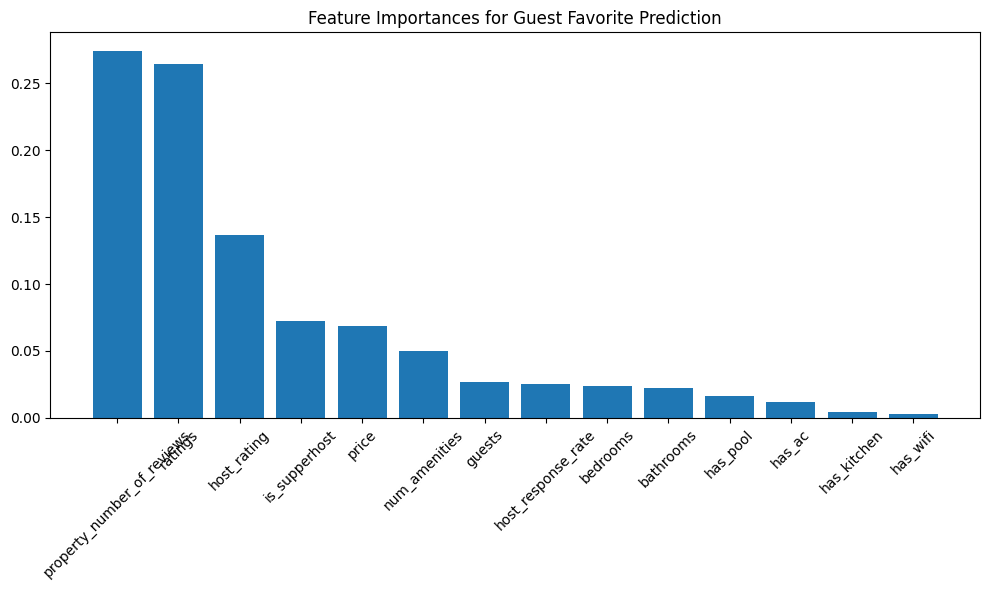

In [101]:
# Feature importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature Importances for Guest Favorite Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [102]:
# ROC Curve
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

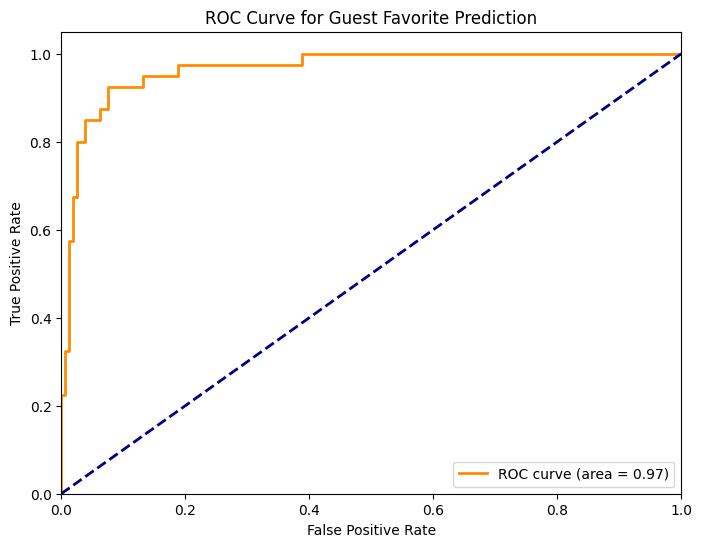

In [103]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Guest Favorite Prediction')
plt.legend(loc="lower right")
plt.show()

In [104]:
# [1. Install required packages]
!pip install ipywidgets
from IPython.display import clear_output
from ipywidgets import widgets, interact, interactive, Layout, Accordion
import ipywidgets as widgets
from google.colab import output
output.enable_custom_widget_manager()

import pandas as pd
import matplotlib.pyplot as plt
import ast

# Load your Airbnb dataset
df = pd.read_excel('/content/drive/MyDrive/Airbnb Properties Information.xlsx')  # <-- replace with actual filename

# Feature extraction
def extract_number_from_list(lst, keyword):
    for item in lst:
        if keyword in item.lower():
            match = re.search(r'(\d+)', item)
            if match:
                return int(match.group(1))
    return 0

# Convert string representation of lists to actual lists
df['details_list'] = df['details'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['amenities_list'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['available_dates_list'] = df['available_dates'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
# Extract features
df['bedrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bedroom'))
df['bathrooms'] = df['details_list'].apply(lambda x: extract_number_from_list(x, 'bath'))
df['num_amenities'] = df['amenities_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)


# Optional cleaning
df['availability'] = pd.to_numeric(df['availability'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['num_amenities'] = pd.to_numeric(df['num_amenities'], errors='coerce')


# [2. Create Login UI]
login_username = widgets.Text(placeholder='Enter username')
login_password = widgets.Password(placeholder='Enter password')
login_button = widgets.Button(description="Login")
login_output = widgets.Output()

def on_login_clicked(b):
    with login_output:
        if login_username.value == "admin" and login_password.value == "admin@1":
            clear_output()
            display(main_dashboard)
            update_visualizations(segmentation_dropdown.value, chart_type_dropdown.value)
        else:
            print("Invalid credentials!")

login_button.on_click(on_login_clicked)
login_ui = widgets.VBox([
    widgets.HTML("<h2>Airbnb Analytics Login</h2>"),
    login_username,
    login_password,
    login_button,
    login_output
])

# [3. Main Dashboard UI]
# Segmentation controls
segmentation_dropdown = widgets.Dropdown(
    options=['Daily', 'Weekly', 'Monthly', 'Yearly'],
    value='Daily',
    description='Segmentation:'
)

chart_type_dropdown = widgets.Dropdown(
    options=['Line Chart', 'Bar Chart', 'Heatmap', 'Pie Chart'],
    value='Line Chart',
    description='Chart Type:'
)

# Create dashboard sections
availability_section = widgets.Accordion(children=[widgets.Output()])
price_section = widgets.Accordion(children=[widgets.Output()])
amenities_section = widgets.Accordion(children=[widgets.Output()])

availability_section.set_title(0, 'Availability Trends')
price_section.set_title(0, 'Pricing Analysis')
amenities_section.set_title(0, 'Amenities Distribution')

# [4. Visualization Functions]
def create_time_based_segmentation(segmentation):
    df['date'] = pd.to_datetime(df['available_dates_list'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
    ), errors='coerce')

    if segmentation == 'Weekly':
        return df.resample('W', on='date').mean(numeric_only=True)
    elif segmentation == 'Monthly':
        return df.resample('M', on='date').mean(numeric_only=True)
    elif segmentation == 'Yearly':
        return df.resample('Y', on='date').mean(numeric_only=True)
    else:  # Added an else for clarity and default behavior
        return df.resample('D', on='date').mean(numeric_only=True)



def update_visualizations(segmentation, chart_type):
    segmented_df = create_time_based_segmentation(segmentation)

    with availability_section.children[0]:
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        if chart_type == 'Line Chart':
            segmented_df['availability'].plot(title=f'Availability ({segmentation})')
        elif chart_type == 'Bar Chart':
            segmented_df['availability'].plot(kind='bar')
        plt.show()

    with price_section.children[0]:
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        if chart_type == 'Line Chart':
            segmented_df['price'].plot(title=f'Pricing ({segmentation})')
        elif chart_type == 'Bar Chart':
            segmented_df['price'].plot(kind='bar')
        plt.show()

    with amenities_section.children[0]:
        clear_output(wait=True)
        plt.figure(figsize=(8, 6))
        df['num_amenities'].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title('Amenities Distribution')
        plt.show()

# [5. Interactive Dashboard]
interactive_update = interactive(
    update_visualizations,
    segmentation=segmentation_dropdown,
    chart_type=chart_type_dropdown
)

main_dashboard = widgets.VBox([
    widgets.HTML("<h1>Airbnb Analytics Dashboard</h1>"),
    widgets.HBox([segmentation_dropdown, chart_type_dropdown]),
    availability_section,
    price_section,
    amenities_section
])

# [6. Display Initial UI]
display(login_ui)


In [105]:
!pip install h5py

In [106]:
import h5py
import numpy as np  # If you're storing NumPy arrays
import pandas as pd # If you're storing Pandas DataFrames